In [ ]:
from functools import reduce
from typing import Callable

from hereutil import here, add_to_sys_path
from sqlframe_gizmosql import Window
add_to_sys_path(here())

from src.common_basis_gizmosql import *
subqueries: list[nw.LazyFrame] = []

### Query

In [2]:
# select the dataset vd17 and data fields
data_fields = ['all_titles', 
               'all_individual_actors',
               'all_publishers', 
               'all_places_of_publication', 
               'all_years_of_publication'
               ]
q = None
for field in data_fields:
    if q is None:
        q = (f(field)
             .filter(c('source').is_in(['vd17']))
             .drop(['field_number', 'field_code'], strict=False)
            )
    else:
        q = q.join(f(field)
                    .filter(c('source').is_in(['vd17']))
                    .drop(['field_number','field_code'], strict=False),
                    how='left', on=['record_number', 'source']
                    )

In [3]:
# get a subset of the queried data: Leipzig, 1616-1620
subset = (q.filter(
                    c('place_of_publication')=='Leipzig',
                    c('year_of_publication').is_between(1616, 1620))
        )
df = subset.collect().to_native().to_pandas()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56082 entries, 0 to 56081
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   record_number         56082 non-null  int32
 1   main_title            56082 non-null  str  
 2   source                56082 non-null  str  
 3   value                 55938 non-null  str  
 4   publisher             55070 non-null  str  
 5   place_of_publication  56082 non-null  str  
 6   place_type            56082 non-null  str  
 7   year_of_publication   56082 non-null  int32
dtypes: int32(2), str(6)
memory usage: 16.0 MB


### Clean author and publisher entries (if needed)

In [4]:
from clean_helpers import *
import pandas as pd

df['authors'] = df.value.apply(lambda x: clean_authors(str(x)) if pd.notna(x) else [])
df['publisher'] = df['publisher'].apply(lambda x: clean_text(x) if pd.notna(x) else '')

**Warnings** : There are instances where a book was published by multiple publishers, sometimes under different authors. We consider such books as sets of separate author-publisher links.

In [5]:
example = df[df['record_number']==77594][['main_title', 'authors', 'publisher' , 'year_of_publication']]
example['authors'] = example['authors'].apply(lambda x: '|'.join([' '.join(list(a)) for a in x]))
example.drop_duplicates()

,main_title,authors,publisher,year_of_publication
25314,Evangelia: Auff alle Sontag,"flanham, christoph",eyering,1617
25433,Evangelia: Auff alle Sontag,"schwetkius, barthol",eyering,1617
25552,Evangelia: Auff alle Sontag,"schickfusius, jacobus",eyering,1617
25669,Evangelia: Auff alle Sontag,"neomenius, johannes",eyering,1617
25779,Evangelia: Auff alle Sontag,"gnd/130442348 hancke, martin",eyering,1617
...,...,...,...,...
32954,Evangelia: Auff alle Sontag,"heilman, andreas",eyering,1617
32956,Evangelia: Auff alle Sontag,"heilman, andreas",perfert,1617
32958,Evangelia: Auff alle Sontag,"heilman, andreas",lamberg,1617
32960,Evangelia: Auff alle Sontag,"heilman, andreas",typis lambergianis,1617


In [ ]:
save_path = # add path to save the data and run to save into .csv
df.to_csv(save_path, index=False)

### Author-Publisher Network

In [6]:
from tqdm import tqdm
import numpy as np
import graph_tool.all as gt

In [11]:
# get one-to-one author-publisher links
elist = df[["authors", "publisher" , "year_of_publication"]].explode("authors")
elist = elist[elist['publisher']!='']
elist.dropna(inplace=True)

# get the author's name only (not gnd identifier) 
elist["author_name"] = elist["authors"].apply(lambda x: x[1]) 

# compute edge weights based on unique year count
elist = elist.groupby(by=["publisher", "author_name"])["year_of_publication"].nunique().reset_index()

elist

,publisher,author_name,year_of_publication
0,abraham lamberg,"hoë von hoënegg, matthias",1
1,abrahami lambergi casparis closmanni,"bomgarde, bernhard",1
2,abrahami lambergi casparis closmanni,"stigel, johann",1
3,aeyringus,"bauerus, andreas",1
4,aeyringus,"höpnerus, paulus",1
...,...,...,...
9853,weidnerus,"bolduan, paul",1
9854,weidnerus,"drenckhan, michael",1
9855,weidnerus,"gottingius, joannes",1
9856,weidnerus,"maderus, joannes",1


In [ ]:
# build the network
g = gt.Graph(directed=False)
vmap = g.add_edge_list(list(zip(elist["publisher"], 
                         elist["author_name"], 
                         elist['year_of_publication'])
                         ), 
                         hashed=True, 
                         eprops=[('weight', 'double')])

vtype = g.new_vertex_property('int')
for v in g.vertices():
    if vmap[v] in set(elist.publisher):
        vtype[v] = 1 # v_type=1 if publisher
    else:
        vtype[v] = 0 # else v_type=0 
g.vp['v_type'] = vtype

In [ ]:
# save graph
save_path = # add path to save graph (.graphml recommended)
g.save(save_path)

### Visualization

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path =  # your font path goes here
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()

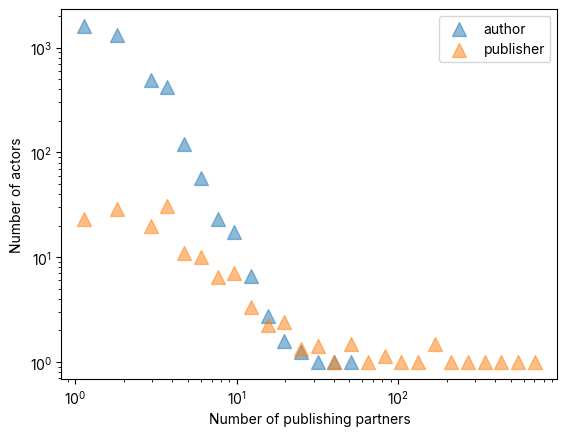

In [14]:
# degree distribution
from scipy.stats import binned_statistic

def bin_degree_sequence(degrees: list, min=1, max=1e3, num=30):
    pdata = pd.Series(degrees).value_counts().sort_index()
    bins = np.geomspace(min, max, num=num)
    bin_counts, bin_edges, _ = binned_statistic(pdata.index, pdata.values, statistic='mean', bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    return bin_counts, bin_centers

deg = g.degree_property_map(deg="total")
upper_degrees = deg.a[np.where(vtype.a == 1)]
lower_degrees = deg.a[np.where(vtype.a == 0)]

bin_counts, bin_centers = bin_degree_sequence(lower_degrees)
plt.scatter(bin_centers, bin_counts, 
            marker='^', s=100, alpha=.5,
            label='author')

bin_counts, bin_centers = bin_degree_sequence(upper_degrees)
plt.scatter(bin_centers, bin_counts, 
            marker='^', s=100,  alpha=.5,
            label='publisher',)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of publishing partners')
plt.ylabel('Number of actors')
plt.legend()

# save_path = # path to save the plot 
# plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# the network

# node color: using node type (publisher, author)
import seaborn as sns
colors = [list(c + (.8,)) for c in list(sns.color_palette("colorblind"))]
vfill= g.new_vertex_property('vector<double>')
for v in g.vertices():
    if vtype[v] == 0:
        vfill[v]=colors[0]
    else:
        vfill[v]=colors[1]

# node size: proportional to node degree
vsize = deg.copy(value_type="float")
vsize.a = np.log(vsize.a)*2

# node label: only label top n nodes with largest degree
n = 10
upper_threshold = upper_degrees[np.argsort(upper_degrees)[-n]]
lower_threshold = lower_degrees[np.argsort(lower_degrees)[-n]]
annot = vmap.copy()
for v in g.vertices():
    if vtype[v] == 0  and deg[v] >= lower_threshold:
        annot[v] = vmap[v]
    if vtype[v] == 1  and deg[v] >= upper_threshold:
        annot[v] = vmap[v]
    else:
        annot[v] = ""

# edge width: proportional to edge weights
ewidth = g.ep.weight.copy()
ewidth.a = np.sqrt(ewidth.a)/10

# layout: SFDP spring-block layout
pos = gt.sfdp_layout(g)

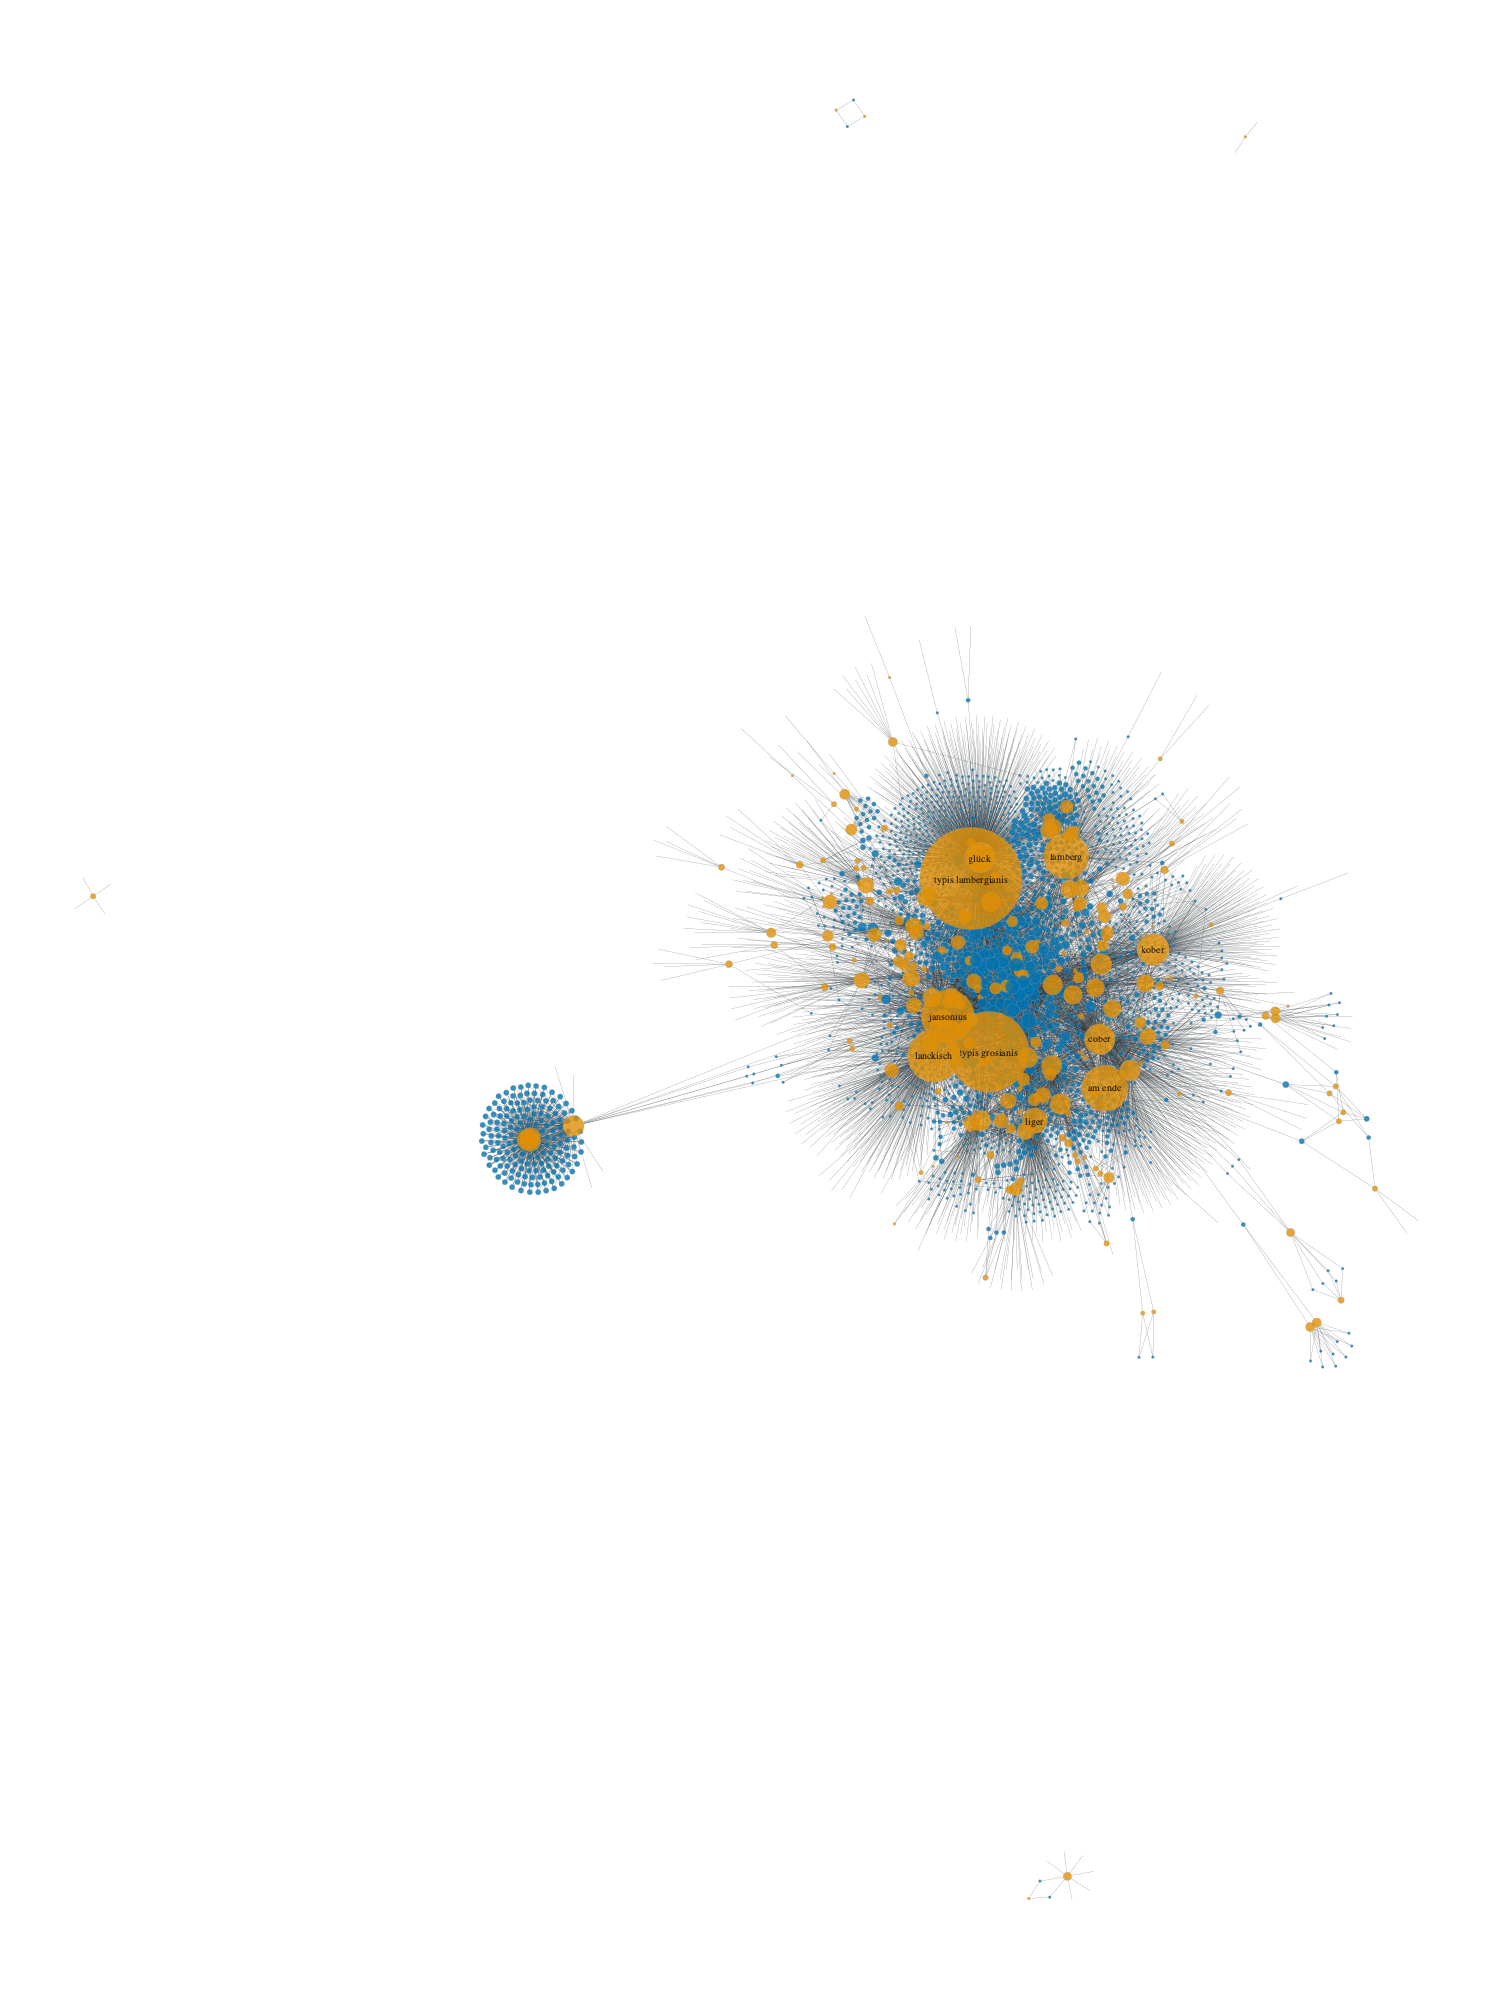

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x25d386990, at 0x27c132c60>

In [21]:
# save_path = # path to save the plot here
gt.graph_draw(g, output_size=(1000, 1000),
              pos=pos, 
              vertex_size=vsize, 
              vertex_fill_color=vfill,
              edge_pen_width=ewidth,
              vertex_text=annot,
              vertex_font_size=5,
              vorder=deg,
            #   output=save_path
              )